In [1]:
# ==========================================
# STEP 0: Mount Drive and Unzip Data Locally
# ==========================================
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print("Extracting dataset to Colab's high-speed local storage...")
# Unzip the dataset from Drive to the local /content/Data/ folder
!unzip -q -n "/content/drive/MyDrive/AIProject/Data/asl-alphabet.zip" -d "/content/Data/"
print("Extraction complete!")

!ls -lah "/content/drive/MyDrive/AIProject/Data"

Mounted at /content/drive
Extracting dataset to Colab's high-speed local storage...
Extraction complete!
total 1.1G
-rw------- 1 root root 1.1G Apr 26  2020 asl-alphabet.zip


In [2]:
!ls "/content/drive/MyDrive/AIProject/Data"

asl-alphabet.zip


In [3]:
# ==========================================
# STEP 1: Setup and Imports (CPU Sequential Mode)
# ==========================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import gc
from tqdm.notebook import tqdm
from skimage import feature
from google.colab import drive

# ML Models & Preprocessing (Standard Scikit-Learn)
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [12]:
# --- CONFIGURATION ---
# Paths
TRAIN_DIR = "/content/Data/asl_alphabet_train/asl_alphabet_train/"
TEST_DIR = "/content/Data/asl_alphabet_test/asl_alphabet_test/"
OUTPUT_DIR = "/content/drive/MyDrive/AIProject/Output/"

# Subfolders
dirs = {
    "FEAT": os.path.join(OUTPUT_DIR, "Features"),
    "MODEL": os.path.join(OUTPUT_DIR, "Models"),
    "METRIC": os.path.join(OUTPUT_DIR, "Metrics"),
    "VAL_CHART": os.path.join(OUTPUT_DIR, "Charts", "Validation"),
    "TS_CHART": os.path.join(OUTPUT_DIR, "Charts", "Test_Split"),
    "FINAL_CHART": os.path.join(OUTPUT_DIR, "Charts", "Final_29")
}

for d in dirs.values():
    os.makedirs(d, exist_ok=True)

# Dataset Parameters
SAMPLE_FRACTION = 1  # Using 5% for testing; set to 1.0 for final run
VOCAB_SIZE = 50         # Reduced slightly to save RAM during clustering

classes = ["A","B","C","D","E","F","G","H","I","J","K","L","M","N","O",
           "P","Q","R","S","T","U","V","W","X","Y","Z","del","nothing","space"]
label_map = {cls: idx for idx, cls in enumerate(classes)}

print("Step 1 Complete: Environment set for CPU Sequential Mode.")

Step 1 Complete: Environment set for CPU Sequential Mode.


In [5]:
# ==========================================
# STEP 2: Feature Extraction Functions
# ==========================================

# Initialize local descriptor extractors
sift = cv2.SIFT_create(nfeatures=50)
orb = cv2.ORB_create(nfeatures=50)

def extract_global_features(img):
    """Extracts HOG, Color Histogram, and Hu Moments (Fixed Length)"""
    # Resize to a standard small size to keep vectors manageable
    img_64 = cv2.resize(img, (64, 64))
    img_gray = cv2.cvtColor(img_64, cv2.COLOR_BGR2GRAY)

    # 1. HOG (Histogram of Oriented Gradients) - Captures edge directions
    hog_feats = feature.hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                            cells_per_block=(2, 2), transform_sqrt=True, block_norm="L1")

    # 2. Color Histogram - Captures color distribution in HSV space
    img_hsv = cv2.cvtColor(img_64, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([img_hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()

    # 3. Hu Moments - Captures structural shape (rotation invariant)
    moments = cv2.moments(img_gray)
    hu_moments = cv2.HuMoments(moments).flatten()
    # Log transform to handle the very small values typical of Hu Moments
    hu_moments = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)

    return np.concatenate((hog_feats, hist, hu_moments))

def extract_local_descriptors(img_gray):
    """Extracts SIFT and ORB descriptors (Variable Length)"""
    _, des_sift = sift.detectAndCompute(img_gray, None)
    _, des_orb = orb.detectAndCompute(img_gray, None)
    return des_sift, des_orb

print("Step 2 Complete: Feature extraction functions defined.")

Step 2 Complete: Feature extraction functions defined.


In [6]:
# ==========================================
# STEP 3: Pass 1 - Build Visual Vocabulary (Sequential)
# ==========================================
print(f"\nPass 1: Gathering paths and sampling {SAMPLE_FRACTION*100}% of data...")

sampled_image_paths = []
for cls in classes:
    folder_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.exists(folder_path): continue

    image_files = os.listdir(folder_path)
    num_samples = max(1, int(len(image_files) * SAMPLE_FRACTION))
    selected_files = np.random.choice(image_files, num_samples, replace=False)

    for img_name in selected_files:
        sampled_image_paths.append((os.path.join(folder_path, img_name), label_map[cls]))

sift_descriptor_list = []
orb_descriptor_list = []

print(f"Extracting local descriptors from {len(sampled_image_paths)} images...")
for path, label in tqdm(sampled_image_paths, desc="Sequential Pass 1"):
    img = cv2.imread(path)
    if img is None: continue

    # Resize and grayscale to speed up processing
    img_gray = cv2.cvtColor(cv2.resize(img, (128, 128)), cv2.COLOR_BGR2GRAY)
    des_sift, des_orb = extract_local_descriptors(img_gray)

    if des_sift is not None: sift_descriptor_list.append(des_sift)
    if des_orb is not None: orb_descriptor_list.append(des_orb)

# Flatten into large matrices for clustering
print("Stacking descriptors...")
all_sift = np.vstack(sift_descriptor_list).astype(np.float32)
all_orb = np.vstack(orb_descriptor_list).astype(np.float32)

# Cleanup early to save RAM
del sift_descriptor_list, orb_descriptor_list
gc.collect()

print(f"Clustering {len(all_sift)} SIFT points into {VOCAB_SIZE} visual words...")
kmeans_sift = MiniBatchKMeans(n_clusters=VOCAB_SIZE, random_state=42, batch_size=1000, n_init=3)
kmeans_sift.fit(all_sift)

print(f"Clustering {len(all_orb)} ORB points into {VOCAB_SIZE} visual words...")
kmeans_orb = MiniBatchKMeans(n_clusters=VOCAB_SIZE, random_state=42, batch_size=1000, n_init=3)
kmeans_orb.fit(all_orb)

# Final Pass 1 Cleanup
del all_sift, all_orb
gc.collect()

print("Step 3 Complete: Visual Vocabulary (Codebooks) built.")


Pass 1: Gathering paths and sampling 100% of data...
Extracting local descriptors from 87000 images...


Sequential Pass 1:   0%|          | 0/87000 [00:00<?, ?it/s]

Stacking descriptors...
Clustering 2740830 SIFT points into 50 visual words...
Clustering 1765985 ORB points into 50 visual words...
Step 3 Complete: Visual Vocabulary (Codebooks) built.


In [7]:
# ==========================================
# STEP 4: Pass 2 - Extract Final Feature Vectors (Sequential)
# ==========================================
print("\nPass 2: Building Final Fixed-Length Feature Vectors (Sequential Processing)...")

X_list = []
y_list = []

# Process one image at a time to keep RAM usage extremely low and stable
for img_path, label in tqdm(sampled_image_paths, desc="Extracting Final Features"):
    img = cv2.imread(img_path)
    if img is None: continue

    # 1. Global Features
    global_feats = extract_global_features(img)

    # 2. Local Descriptors
    img_gray = cv2.cvtColor(cv2.resize(img, (128, 128)), cv2.COLOR_BGR2GRAY)
    des_sift, des_orb = extract_local_descriptors(img_gray)

    # 3. Histogram Generation (Bag of Visual Words)
    sift_hist = np.zeros(VOCAB_SIZE, dtype=np.float32)
    if des_sift is not None:
        words = kmeans_sift.predict(des_sift.astype(np.float32))
        for w in words: sift_hist[w] += 1

    orb_hist = np.zeros(VOCAB_SIZE, dtype=np.float32)
    if des_orb is not None:
        words = kmeans_orb.predict(des_orb.astype(np.float32))
        for w in words: orb_hist[w] += 1

    # Combine into one flat vector
    final_vector = np.concatenate((global_feats, sift_hist, orb_hist)).astype(np.float32)

    X_list.append(final_vector)
    y_list.append(label)

print("Stacking final feature arrays...")
# Convert to float32 immediately to cut RAM usage by 50%
X_raw = np.array(X_list, dtype=np.float32)
y = np.array(y_list)

# CRITICAL SCRUB: Delete the Python lists
del X_list, y_list
gc.collect()

print("Saving feature arrays to disk...")
np.save(os.path.join(dirs["FEAT"], "X_advanced_features.npy"), X_raw)
np.save(os.path.join(dirs["FEAT"], "y_advanced_labels.npy"), y)

print(f"✅ Step 4 Complete! Final Feature Vector Shape: {X_raw.shape}")

# Cleanup environment prep for Step 5
try:
    del sampled_image_paths
    gc.collect()
    print("Intermediate data cleared. RAM is ready for Training.")
except NameError:
    pass


print("Saving KMeans models to Google Drive for Step 8...")
joblib.dump(kmeans_sift, os.path.join(dirs["MODEL"], "kmeans_sift.pkl"))
joblib.dump(kmeans_orb, os.path.join(dirs["MODEL"], "kmeans_orb.pkl"))

print("Scrubbing KMeans models from active RAM...")
try:
    del kmeans_sift
    del kmeans_orb
    gc.collect()
    print("✅ RAM optimized! Models safely stored on disk.")
except NameError:
    pass


Pass 2: Building Final Fixed-Length Feature Vectors (Sequential Processing)...


Extracting Final Features:   0%|          | 0/87000 [00:00<?, ?it/s]

Stacking final feature arrays...
Saving feature arrays to disk...
✅ Step 4 Complete! Final Feature Vector Shape: (87000, 2383)
Intermediate data cleared. RAM is ready for Training.
Saving KMeans models to Google Drive for Step 8...
Scrubbing KMeans models from active RAM...
✅ RAM optimized! Models safely stored on disk.


In [8]:
# ==========================================
# STEP 5: ML Pipeline (CPU Sequential Mode)
# ==========================================
print("\nPreparing ML Pipeline (80% Train, 10% Val, 10% Test)...")

# 1. Standard CPU Split (Using sklearn)
X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test_split, y_val, y_test_split = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Data Split Sizes - Train: {len(X_train)} | Val: {len(X_val)} | Test Split: {len(X_test_split)}")

# Memory Scrub: Delete X_raw because we have our splits now
del X_raw, X_temp, y_temp
gc.collect()

# 2. Scaling (StandardScaler from sklearn)
print("\nScaling Features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_split_scaled = scaler.transform(X_test_split)

# Memory Scrub: Delete unscaled data
del X_train, X_val, X_test_split
gc.collect()

# 3. PCA (Dimensionality Reduction)
print("\nRunning PCA (Targeting 95% Variance)...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_split_pca = pca.transform(X_test_split_scaled)

print(f"PCA reduced features to {X_train_pca.shape[1]} dimensions.")

# Memory Scrub: Delete scaled data to save RAM for the models
del X_train_scaled, X_val_scaled, X_test_split_scaled
gc.collect()

# ==========================================
# STRICTLY CPU ML MODELS
# ==========================================
print("\nInitializing Models (n_jobs=1 for strict RAM control)...")

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=1, random_state=42),
    "Log Regression": LogisticRegression(max_iter=1000, n_jobs=1, random_state=42),
    "SVM Linear": SVC(kernel='linear', C=1.0, random_state=42),
    "SVM RBF": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=5),
        n_estimators=50, # Reduced for CPU speed
        learning_rate=0.5,
        random_state=42
    ),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=15),
        n_estimators=50, # Reduced for CPU speed
        max_samples=0.8,
        max_features=0.8,
        n_jobs=1, # STRICTLY 1 to avoid RAM cloning
        random_state=42
    )
}

val_results = []
test_split_results = []
val_predictions = {}
test_split_predictions = {}

pbar = tqdm(total=len(models), desc="Overall Training Progress")

for name, model in models.items():
    pbar.set_description(f"Training: {name}")
    start_time = time.time()

    # --- TRAINING ---
    model.fit(X_train_pca, y_train)

    duration = time.time() - start_time
    mins, secs = divmod(duration, 60)
    pbar.update(1)
    pbar.set_postfix({"Last": name, "Time": f"{int(mins)}m{int(secs)}s"})

    # --- INFERENCE ---
    y_val_pred = model.predict(X_val_pca)
    y_ts_pred = model.predict(X_test_split_pca)

    # --- METRICS (Validation) ---
    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

    val_results.append({"Model": name, "Accuracy": val_acc, "Precision": val_prec, "Recall": val_rec, "F1-Score": val_f1})
    val_predictions[name] = y_val_pred

    # --- METRICS (Test Split) ---
    ts_acc = accuracy_score(y_test_split, y_ts_pred)
    ts_prec = precision_score(y_test_split, y_ts_pred, average='macro', zero_division=0)
    ts_rec = recall_score(y_test_split, y_ts_pred, average='macro', zero_division=0)
    ts_f1 = f1_score(y_test_split, y_ts_pred, average='macro', zero_division=0)

    test_split_results.append({"Model": name, "Accuracy": ts_acc, "Precision": ts_prec, "Recall": ts_rec, "F1-Score": ts_f1})
    test_split_predictions[name] = y_ts_pred

    # Save Model to Google Drive
    joblib.dump(model, os.path.join(dirs["MODEL"], f"{name.replace(' ', '_')}_model.pkl"))

    # Clean up garbage after every model finishes
    gc.collect()

pbar.close()
print(f"\nPipeline finished! Models saved to {dirs['MODEL']}")


Preparing ML Pipeline (80% Train, 10% Val, 10% Test)...
Data Split Sizes - Train: 69600 | Val: 8700 | Test Split: 8700

Scaling Features...

Running PCA (Targeting 95% Variance)...
PCA reduced features to 762 dimensions.

Initializing Models (n_jobs=1 for strict RAM control)...


Overall Training Progress:   0%|          | 0/6 [00:00<?, ?it/s]


Pipeline finished! Models saved to /content/drive/MyDrive/AIProject/Output/Models


In [9]:
# Helper function to plot individual confusion matrices
def plot_individual_cms(y_true, predictions_dict, split_name, save_dir, cmap="Blues"):
    """Generates and saves individual confusion matrix charts for each model."""
    for name, y_pred in predictions_dict.items():
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
        sns.heatmap(cm, cmap=cmap, annot=True, fmt='d', annot_kws={"size": 8}, xticklabels=classes, yticklabels=classes)
        plt.title(f"{name} - {split_name} Confusion Matrix", fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.xticks(rotation=90)
        plt.tight_layout()

        # Save to the specific subfolder
        safe_name = name.replace(' ', '_')
        safe_split = split_name.lower().replace(' ', '_')
        plt.savefig(os.path.join(save_dir, f"{safe_split}_{safe_name}_cm.png"), dpi=300) # <-- Uses save_dir
        plt.show()
        plt.close()


--- GENERATING VALIDATION SET CHARTS (10% Split) ---
Validation metrics saved to CSV.


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.993678,0.993821,0.993678,0.993697
1,Log Regression,0.995517,0.995542,0.995517,0.995517
2,SVM Linear,0.997586,0.997608,0.997586,0.997590
3,SVM RBF,0.997356,0.997384,0.997356,0.997357
4,AdaBoost,0.547011,0.584829,0.547011,0.555493
5,Bagging,0.951379,0.952855,0.951379,0.951527


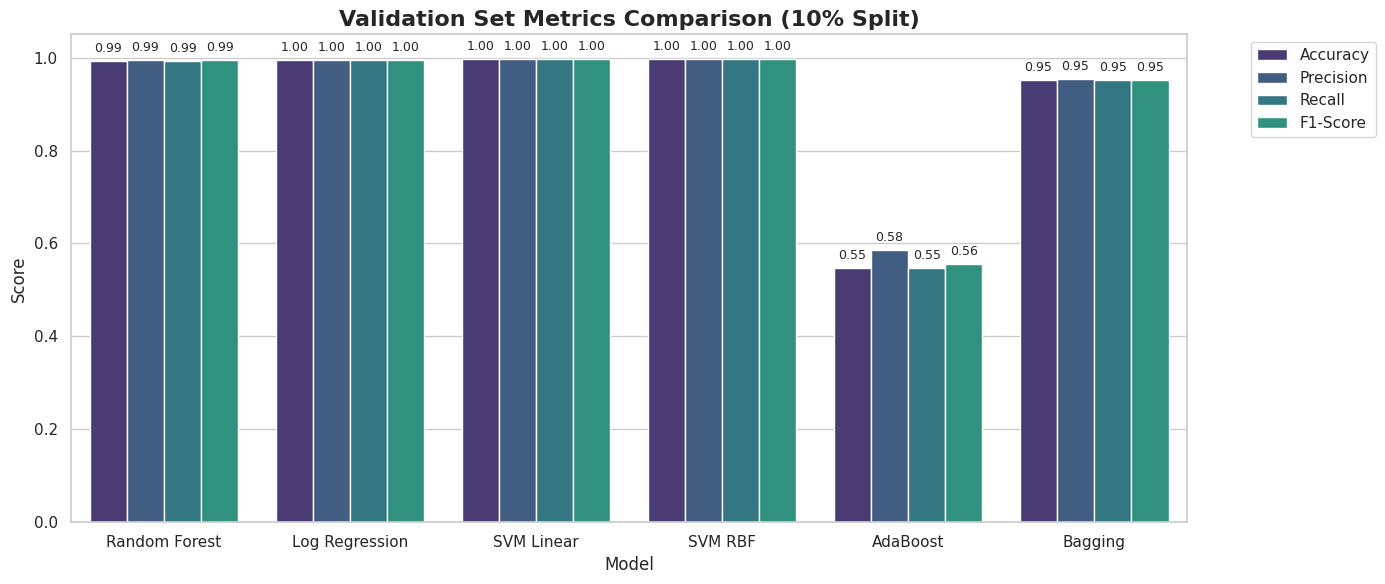


Generating Confusion Matrices for Validation...


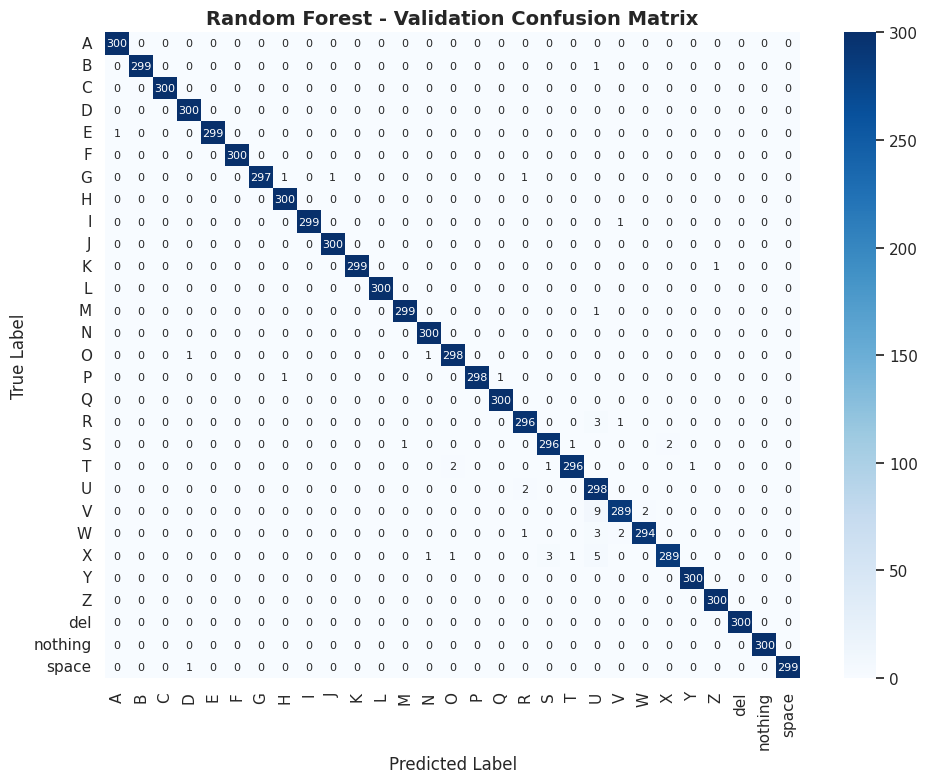

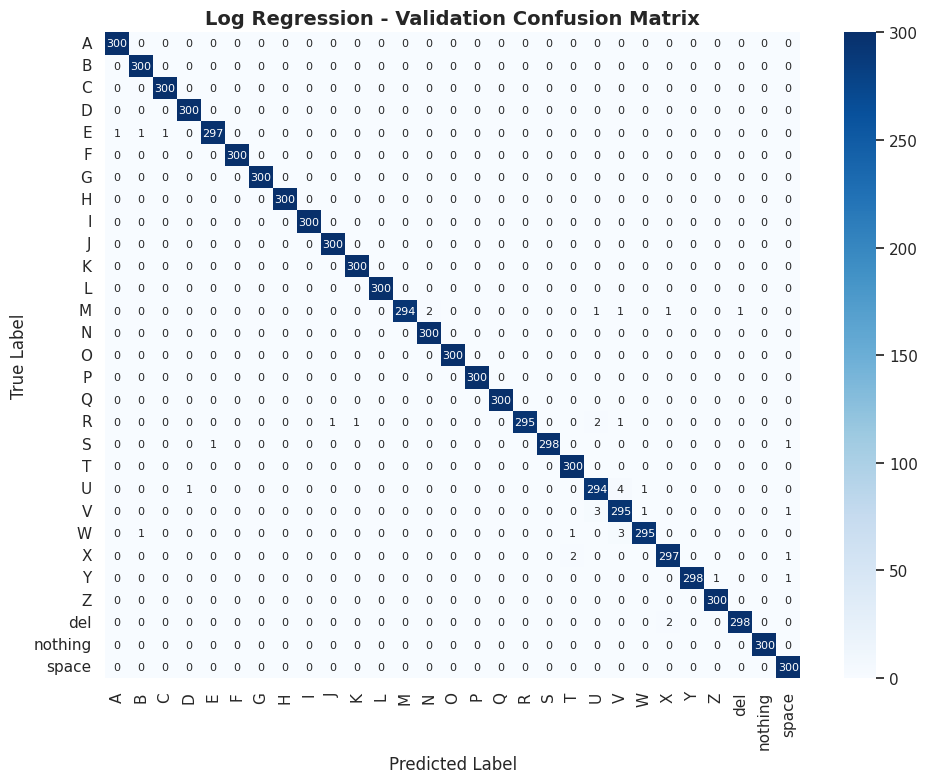

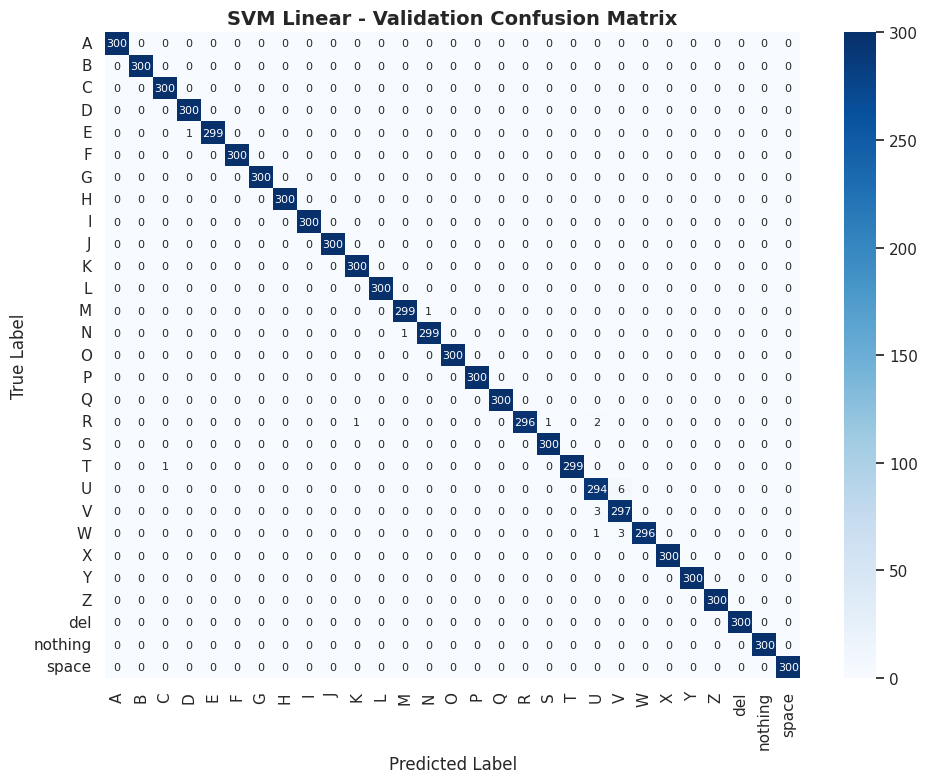

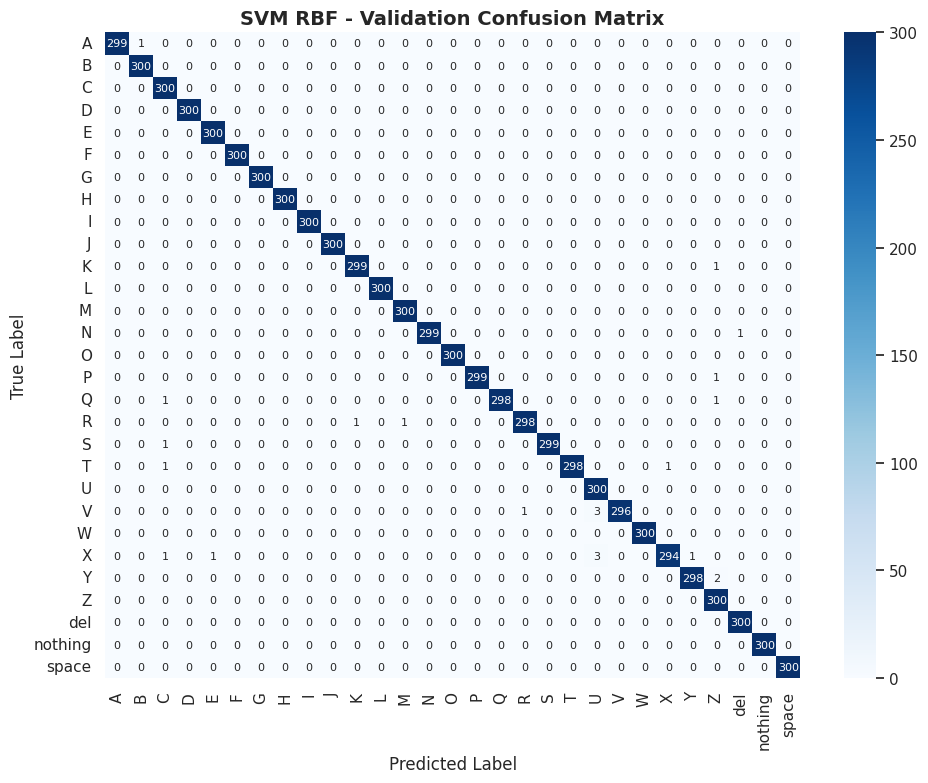

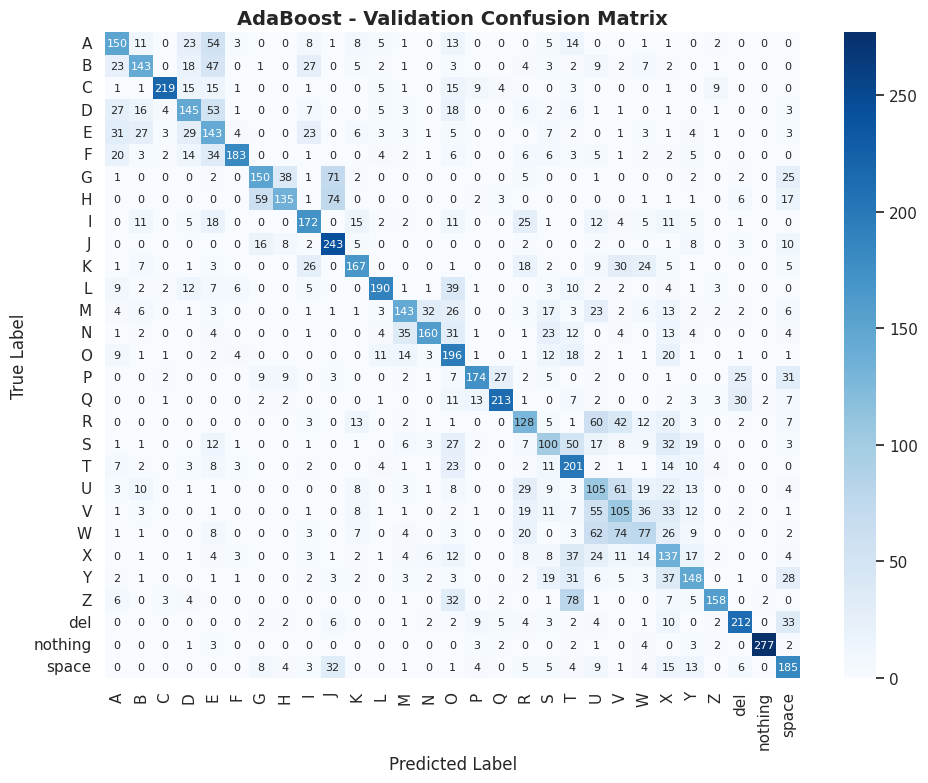

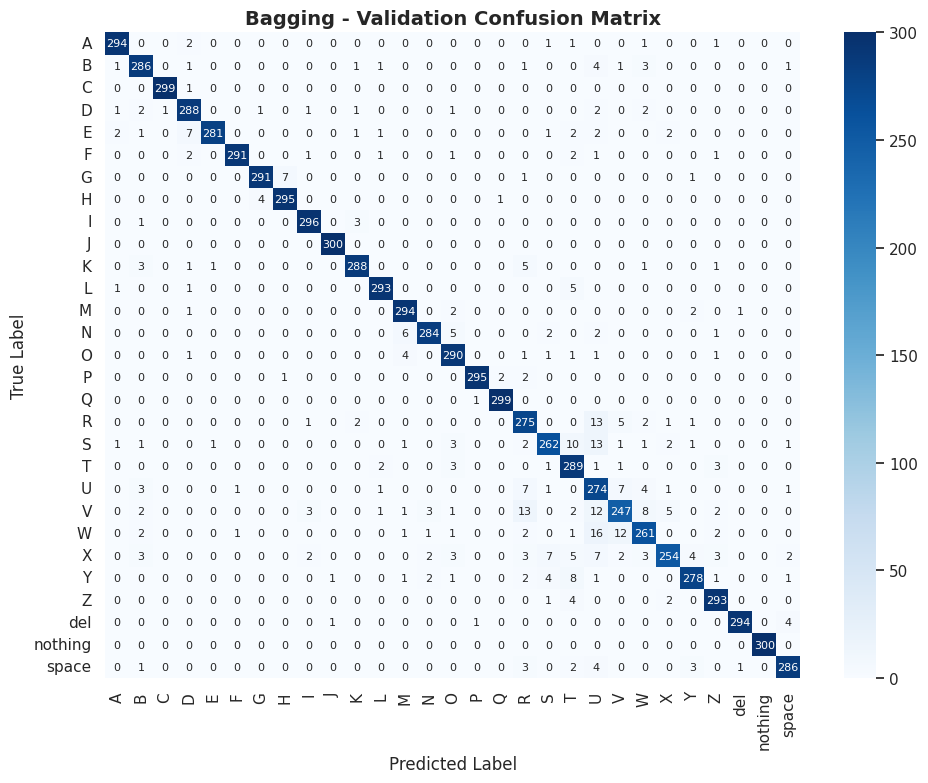

In [13]:
# ==========================================
# STEP 6: Validation Visualizations (10% Split)
# ==========================================
print("\n--- GENERATING VALIDATION SET CHARTS (10% Split) ---")

# 1. Display and Save Validation Metrics to CSV
val_df = pd.DataFrame(val_results)
val_df.to_csv(os.path.join(dirs["METRIC"], "validation_metrics.csv"), index=False)
print("Validation metrics saved to CSV.")
display(val_df) # Use print(val_df) if display() throws an error in your environment

# 2. Validation Bar Chart
sns.set_theme(style="whitegrid", palette="viridis")
df_melted_val = val_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
barplot = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted_val)
plt.title("Validation Set Metrics Comparison (10% Split)", fontsize=16, fontweight='bold')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add the exact numbers on top of the bars
for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(format(p.get_height(), '.2f'),
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(dirs["VAL_CHART"], "validation_bar_chart.png"), dpi=300)
plt.show()

# 3. Helper Function for Confusion Matrices
def plot_individual_cms(y_true, predictions_dict, split_name, save_dir, cmap="Blues"):
    """Generates and saves individual confusion matrix charts for each model."""
    print(f"\nGenerating Confusion Matrices for {split_name}...")
    for name, y_pred in predictions_dict.items():
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
        sns.heatmap(cm, cmap=cmap, annot=True, fmt='d', annot_kws={"size": 8}, xticklabels=classes, yticklabels=classes)

        plt.title(f"{name} - {split_name} Confusion Matrix", fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.xticks(rotation=90)
        plt.tight_layout()

        # Save to the specific subfolder
        safe_name = name.replace(' ', '_')
        safe_split = split_name.lower().replace(' ', '_')
        plt.savefig(os.path.join(save_dir, f"{safe_split}_{safe_name}_cm.png"), dpi=300)
        plt.show()
        plt.close()

# 4. Generate Validation Confusion Matrices
plot_individual_cms(y_val, val_predictions, "Validation", dirs["VAL_CHART"], cmap="Blues")


--- GENERATING TEST SPLIT CHARTS (10% Split) ---
Test Split metrics saved to CSV.


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.990575,0.990689,0.990575,0.990583
1,Log Regression,0.993678,0.993700,0.993678,0.993682
2,SVM Linear,0.997586,0.997589,0.997586,0.997585
3,SVM RBF,0.998161,0.998179,0.998161,0.998163
4,AdaBoost,0.562759,0.598399,0.562759,0.571919
5,Bagging,0.945402,0.947763,0.945402,0.945769


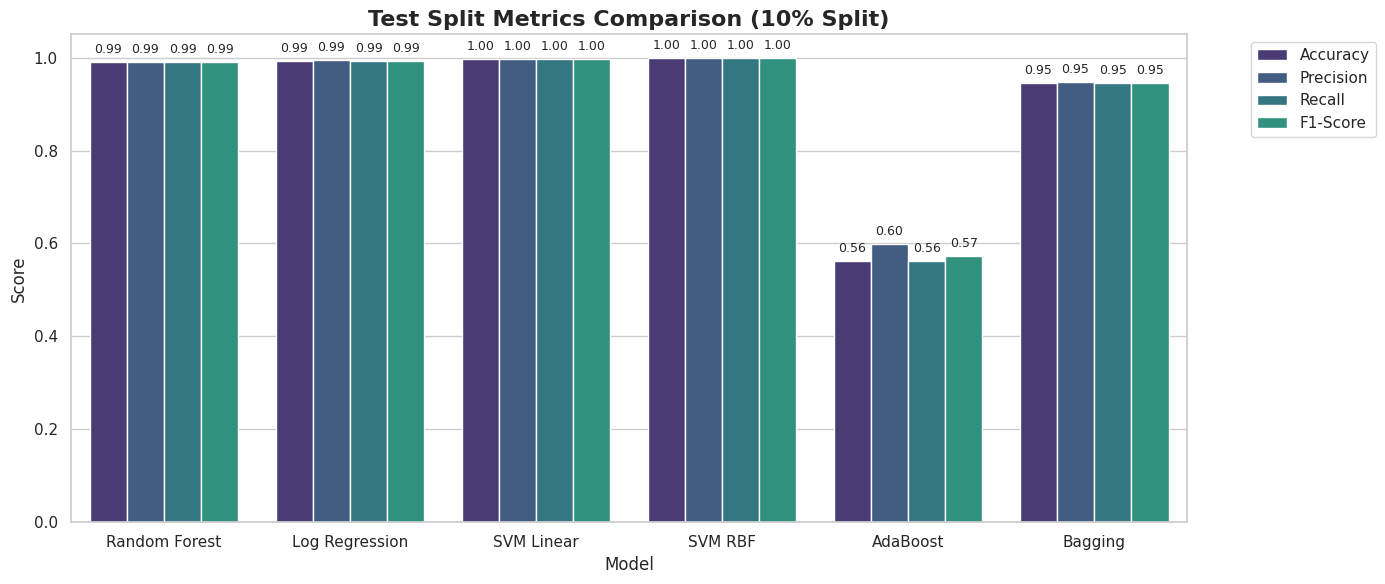


Generating Confusion Matrices for Test Split...

Generating Confusion Matrices for Test Split...


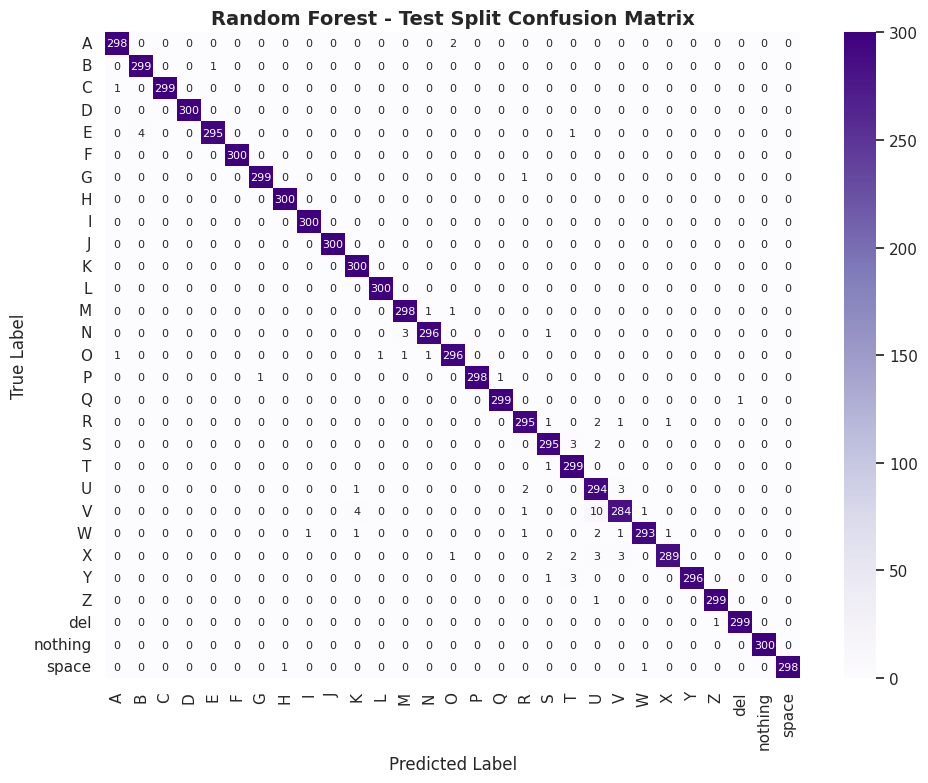

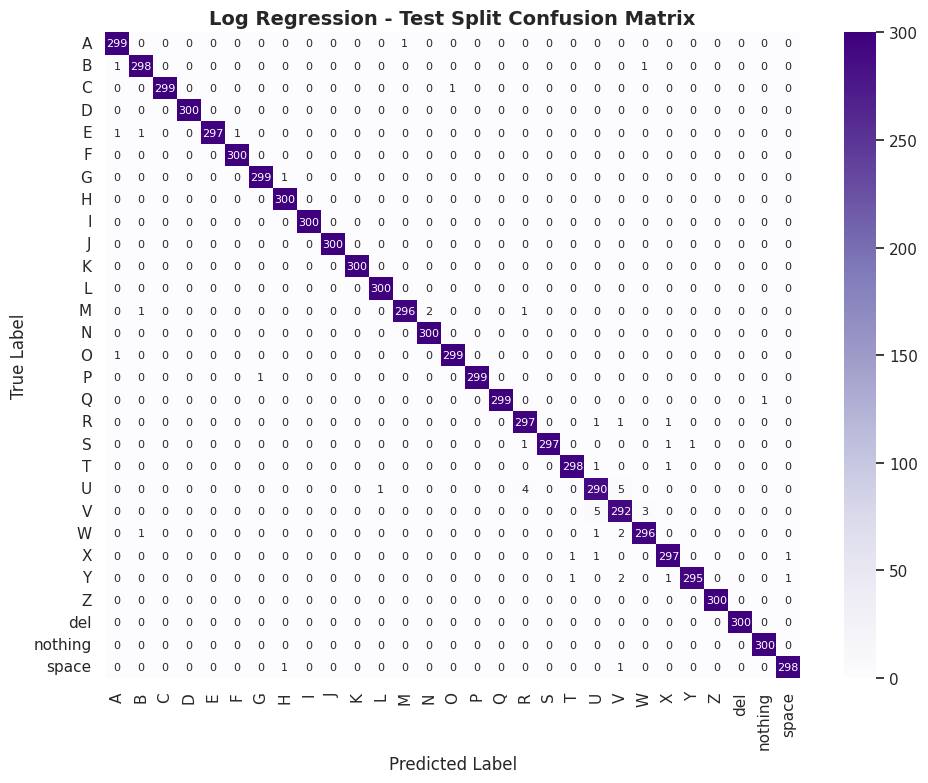

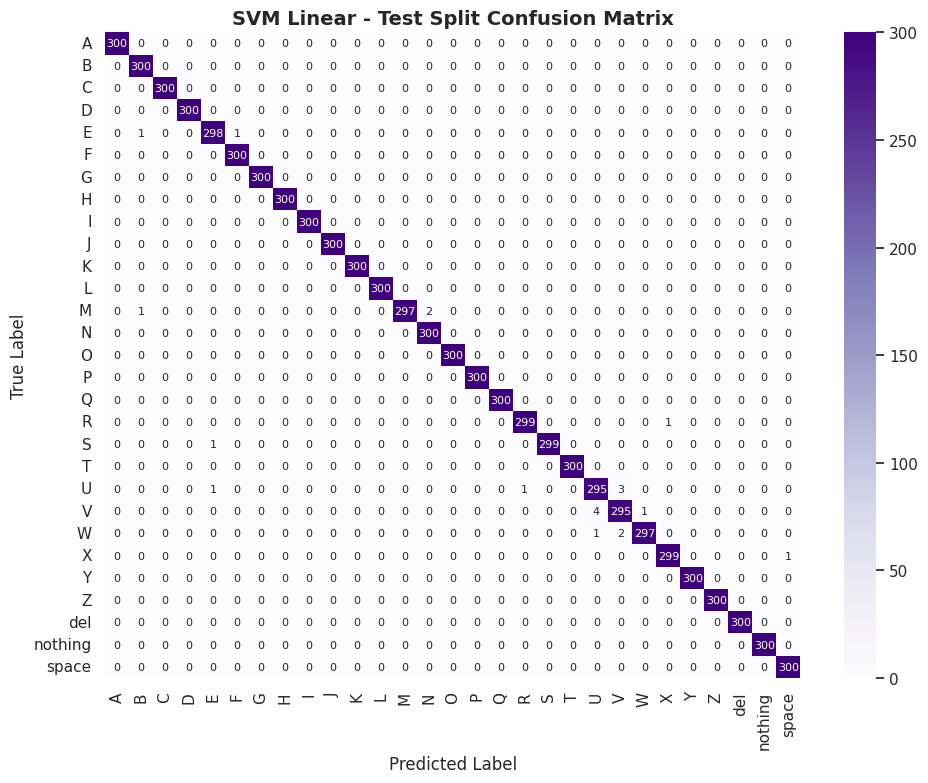

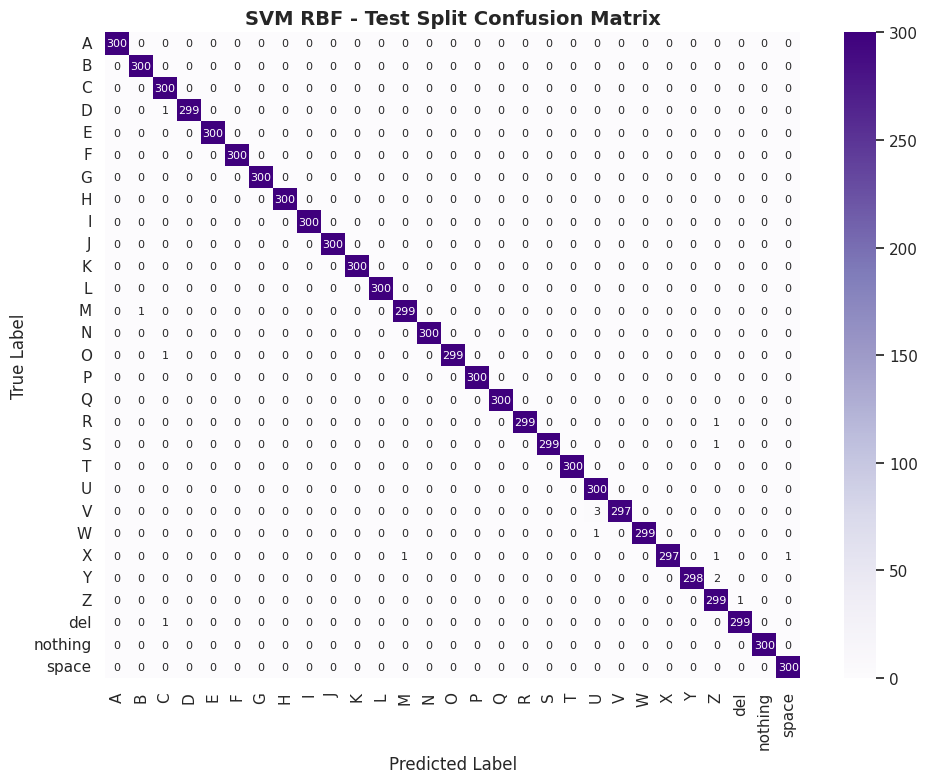

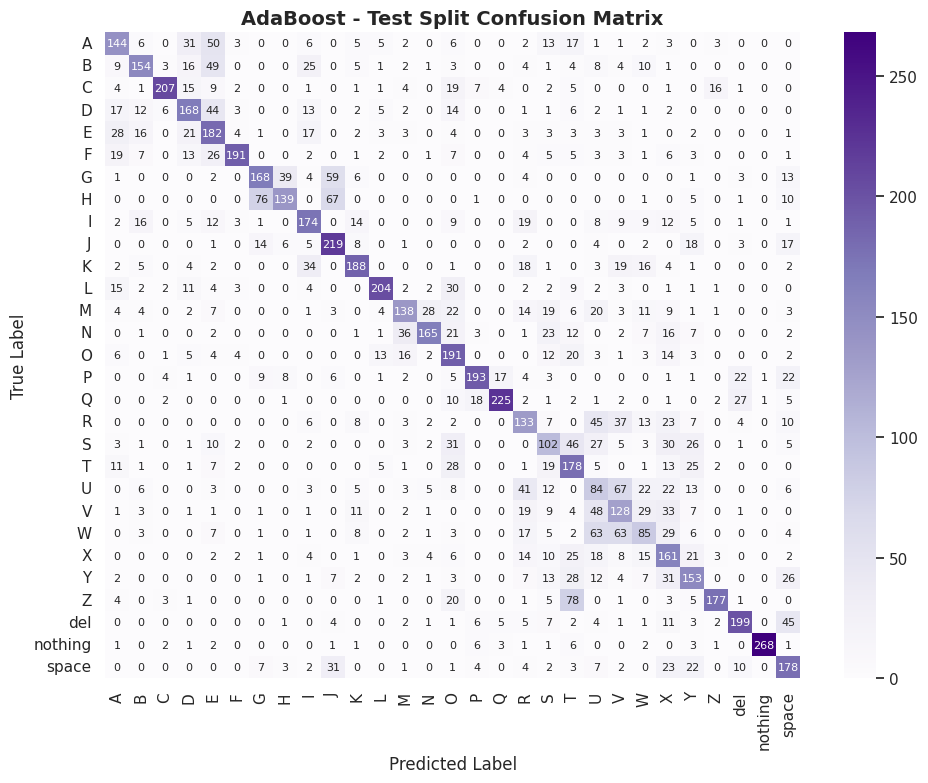

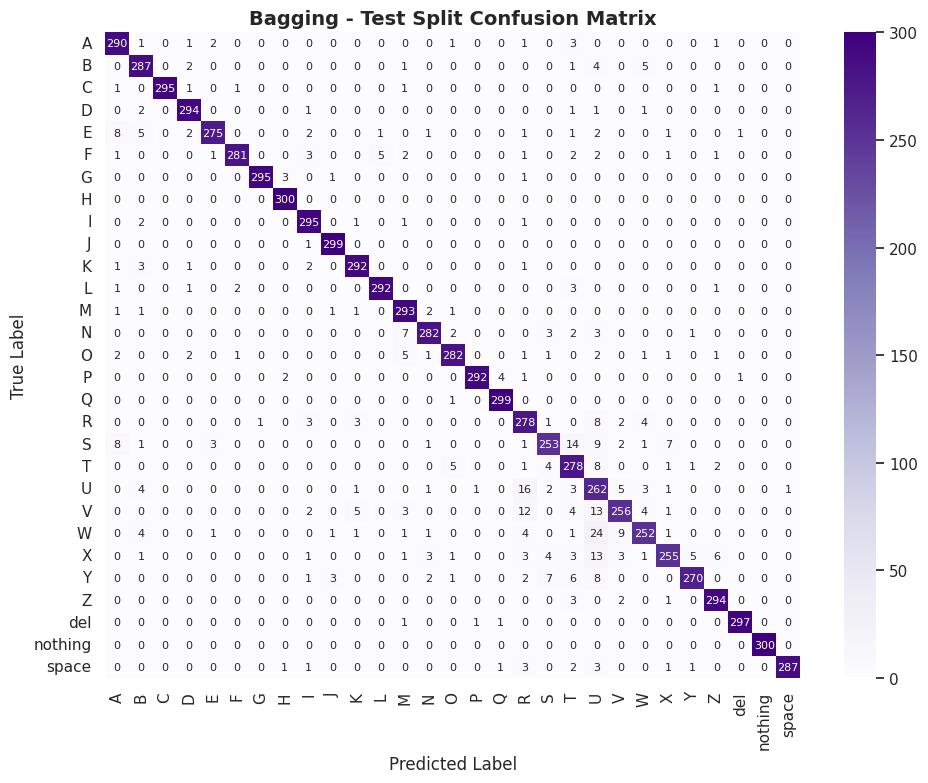

In [15]:
# ==========================================
# STEP 7: Test Split Visualizations (10% Split)
# ==========================================
print("\n--- GENERATING TEST SPLIT CHARTS (10% Split) ---")

# 1. Display and Save Test Split Metrics to CSV
ts_df = pd.DataFrame(test_split_results)
ts_df.to_csv(os.path.join(dirs["METRIC"], "test_split_metrics.csv"), index=False)
print("Test Split metrics saved to CSV.")
display(ts_df) # Use print(ts_df) if display() throws an error

# 2. Test Split Bar Chart
df_melted_ts = ts_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 6))
barplot = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted_ts)
plt.title("Test Split Metrics Comparison (10% Split)", fontsize=16, fontweight='bold')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add the exact numbers on top of the bars
for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(format(p.get_height(), '.2f'),
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(dirs["TS_CHART"], "test_split_bar_chart.png"), dpi=300)
plt.show()

# 3. Generate Test Split Confusion Matrices
# Note: This relies on the `plot_individual_cms` function we defined in Step 6!
print("\nGenerating Confusion Matrices for Test Split...")
plot_individual_cms(y_test_split, test_split_predictions, "Test Split", dirs["TS_CHART"], cmap="Purples")


--- INITIATING FINAL TEST SET EVALUATION (29 Images) ---
Loading KMeans models from Drive...


Extracting Final Test Features:   0%|          | 0/28 [00:00<?, ?it/s]


Applying Scaling and PCA...
Running predictions on the 29 unseen images...

--- FINAL TEST METRICS ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,1.000000,1.000000,1.000000,1.000000
1,Log Regression,1.000000,1.000000,1.000000,1.000000
2,SVM Linear,1.000000,1.000000,1.000000,1.000000
3,SVM RBF,1.000000,1.000000,1.000000,1.000000
4,AdaBoost,0.607143,0.545977,0.586207,0.557471
5,Bagging,1.000000,1.000000,1.000000,1.000000


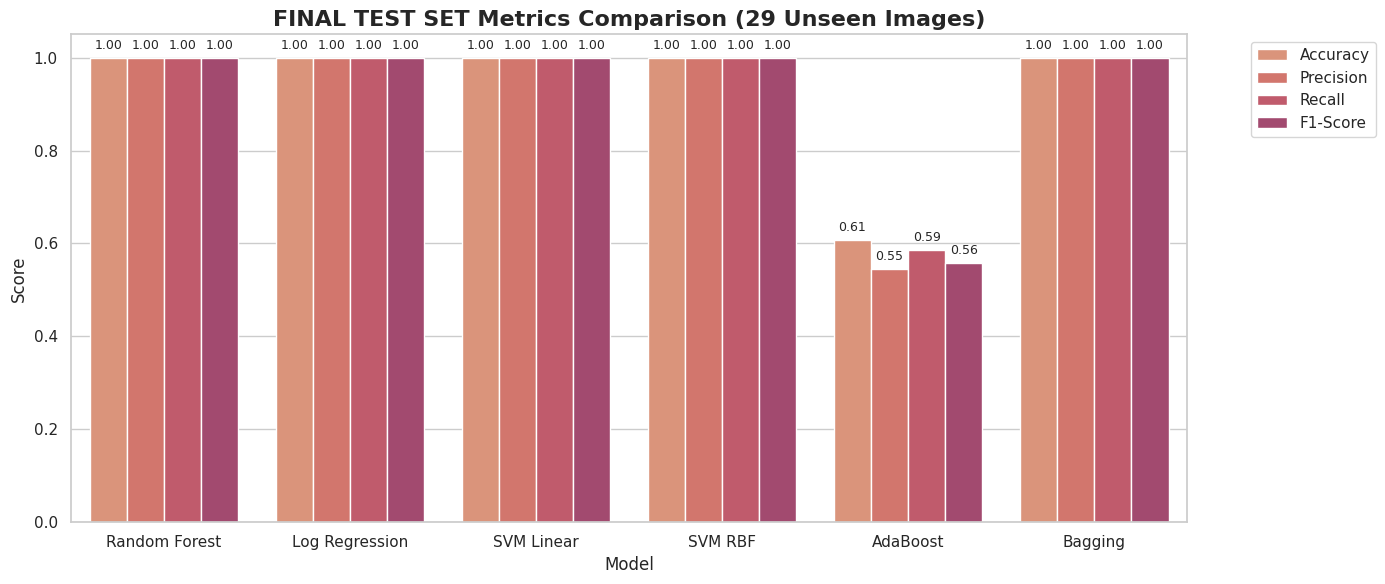


Generating Confusion Matrices for Final Test Set...

Generating Confusion Matrices for Final 29 Test...


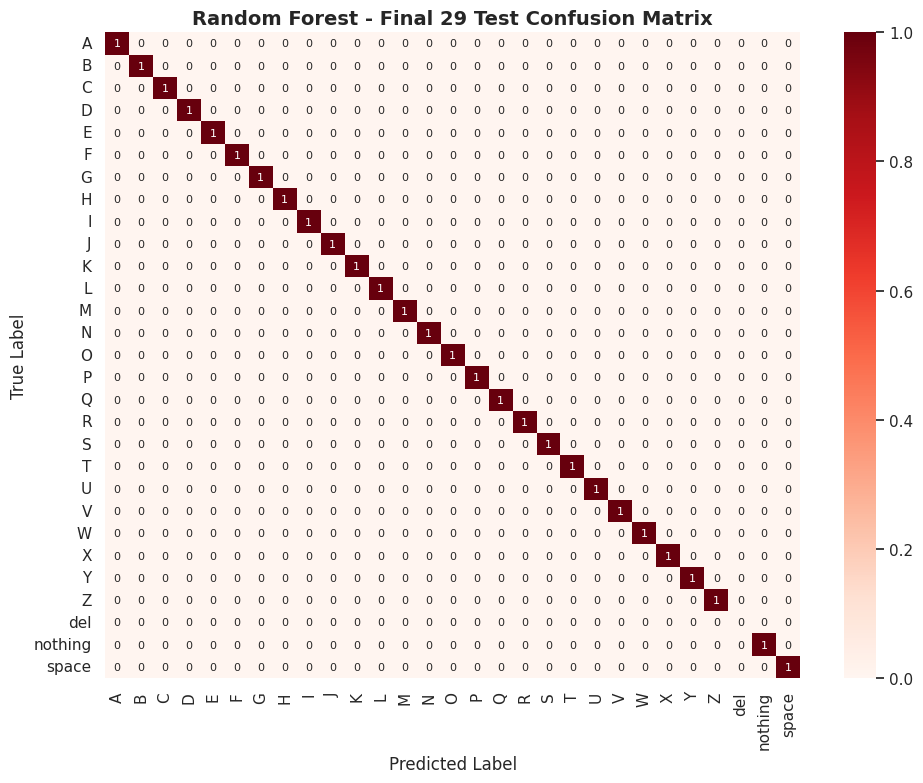

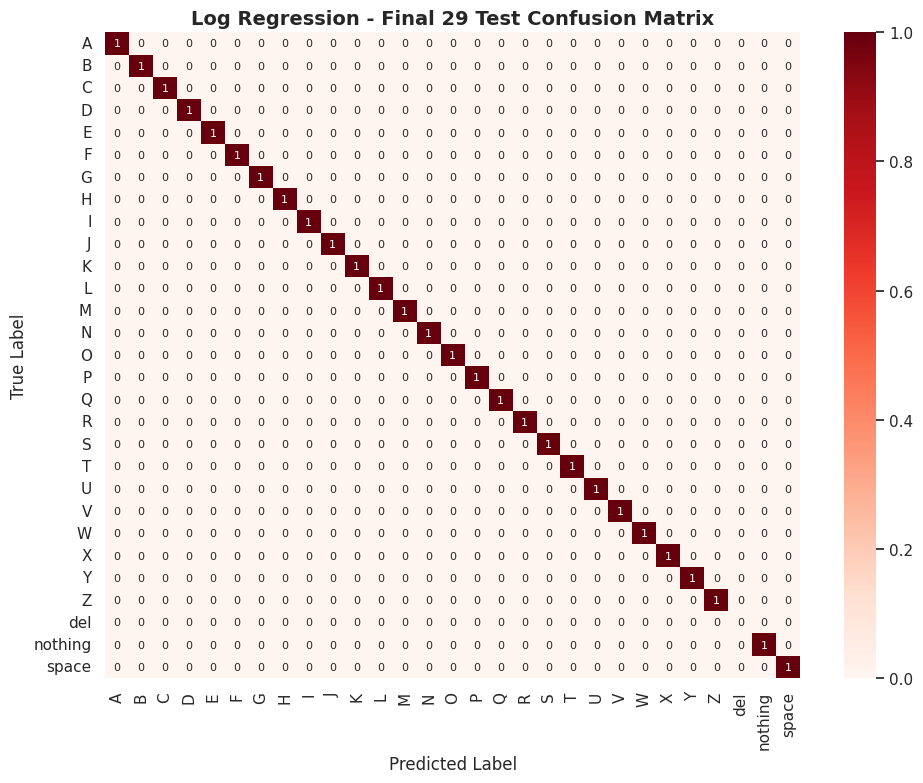

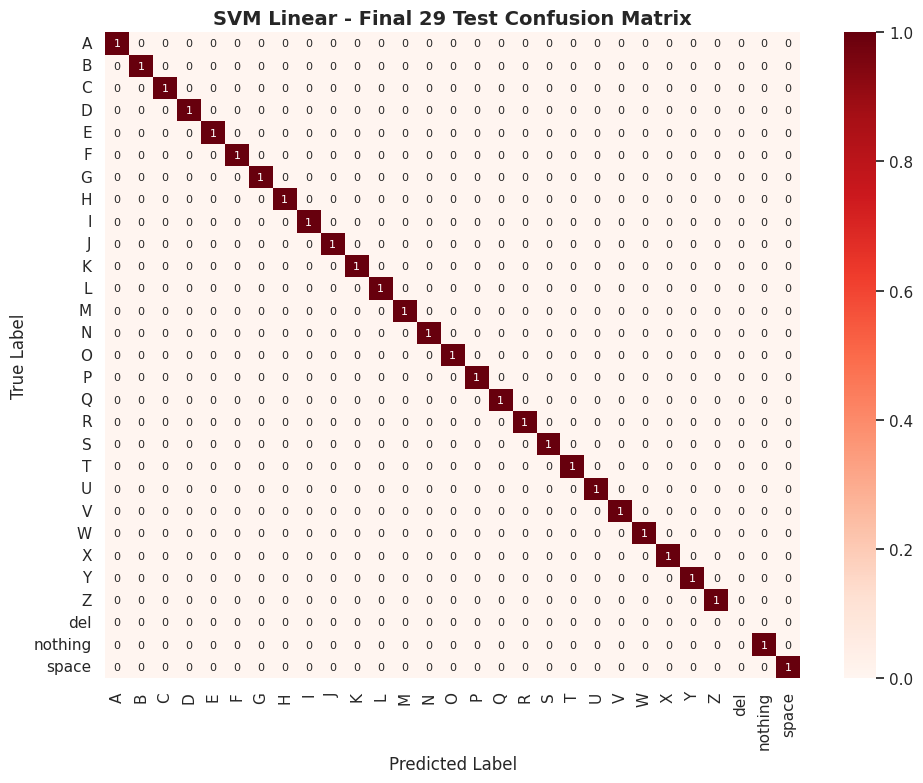

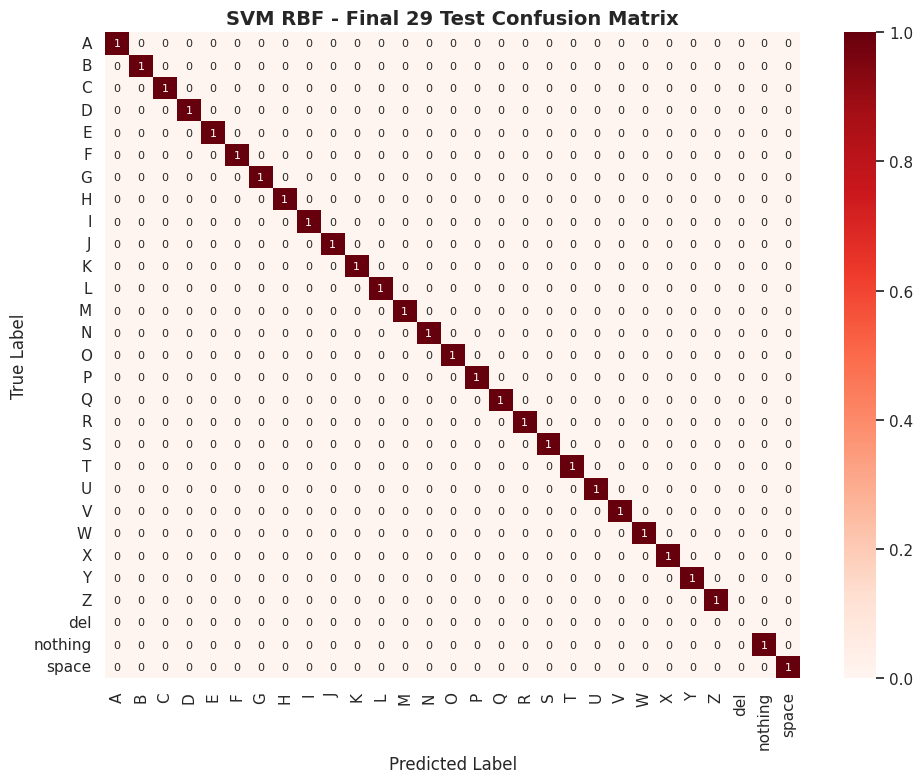

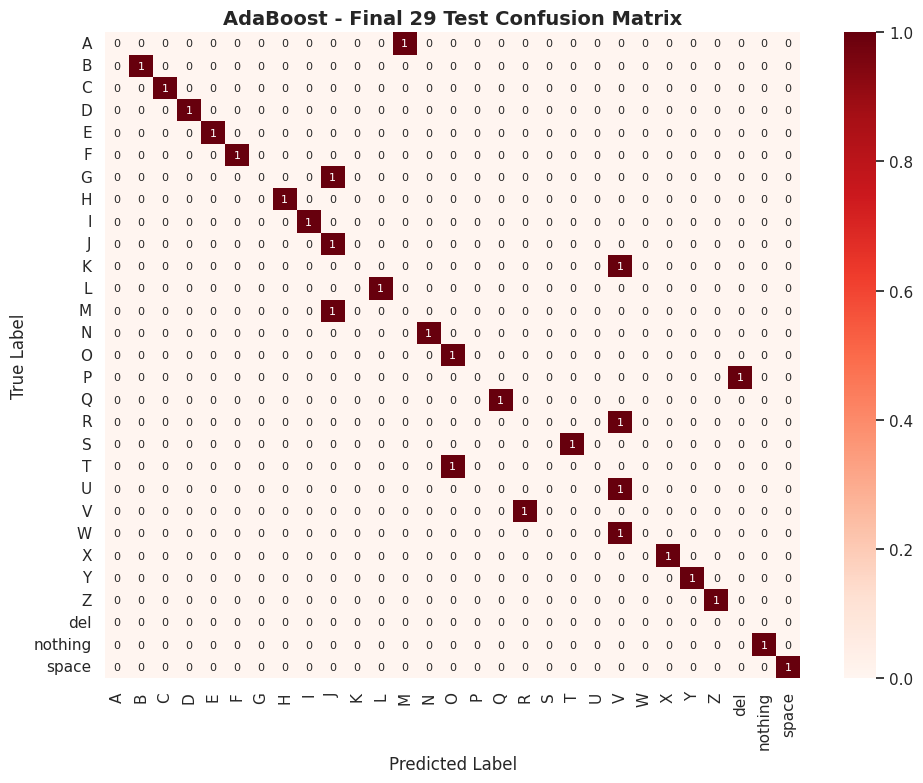

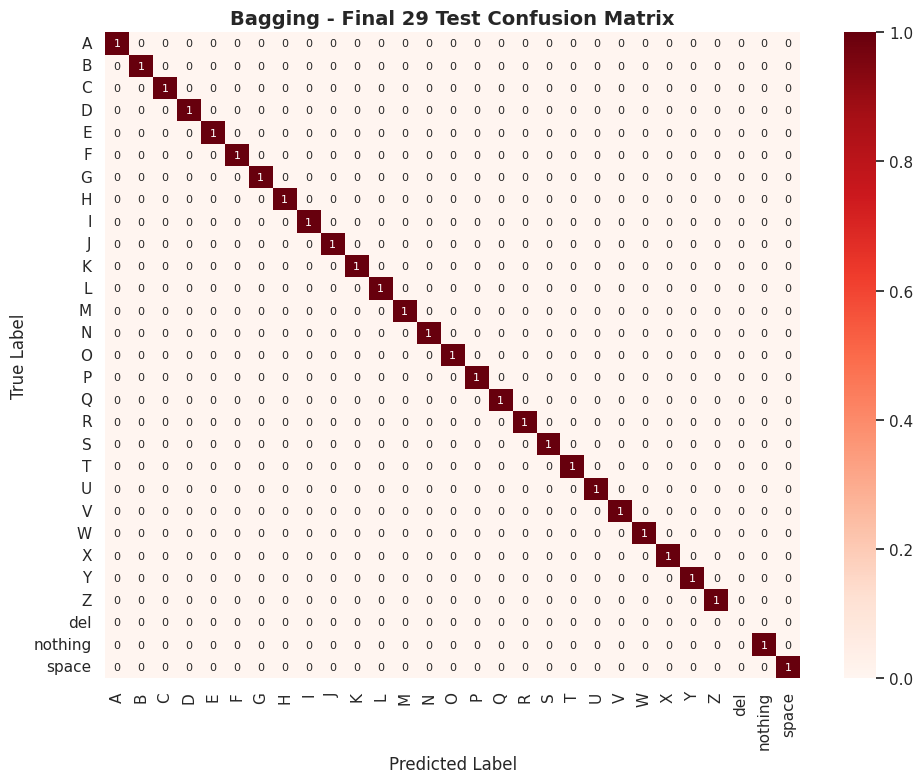


🎉 PIPELINE COMPLETELY FINISHED! All data, models, and charts saved successfully to /content/drive/MyDrive/AIProject/Output/


In [17]:
# ==========================================
# STEP 8: Final Test Set Evaluation (29 Images)
# ==========================================
print("\n--- INITIATING FINAL TEST SET EVALUATION (29 Images) ---")
X_final_raw = []
y_final_true = []

# 1. Reload the Visual Vocabulary Models from Disk
print("Loading KMeans models from Drive...")
kmeans_sift = joblib.load(os.path.join(dirs["MODEL"], "kmeans_sift.pkl"))
kmeans_orb = joblib.load(os.path.join(dirs["MODEL"], "kmeans_orb.pkl"))

if os.path.exists(TEST_DIR):
    test_files = [f for f in os.listdir(TEST_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if len(test_files) == 0:
        print("⚠️ No test images found in the TEST_DIR. Please check your folder.")
    else:
        # 2. Extract Features for the 29 Images
        for f in tqdm(test_files, desc="Extracting Final Test Features"):
            # In the ASL dataset, test images are usually named like "A_test.jpg"
            label_str = f.split('_')[0]
            if label_str not in label_map: continue

            img_path = os.path.join(TEST_DIR, f)
            img = cv2.imread(img_path)
            if img is None: continue

            # Global Features
            gf = extract_global_features(img)

            # Local Features
            img_gray = cv2.cvtColor(cv2.resize(img, (128, 128)), cv2.COLOR_BGR2GRAY)
            ds, do = extract_local_descriptors(img_gray)

            # Build Histograms
            sh, oh = np.zeros(VOCAB_SIZE, dtype=np.float32), np.zeros(VOCAB_SIZE, dtype=np.float32)
            if ds is not None:
                words = kmeans_sift.predict(ds.astype(np.float32))
                for w in words: sh[w] += 1
            if do is not None:
                words = kmeans_orb.predict(do.astype(np.float32))
                for w in words: oh[w] += 1

            X_final_raw.append(np.concatenate((gf, sh, oh)).astype(np.float32))
            y_final_true.append(label_map[label_str])

        # 3. Process and Predict
        if len(X_final_raw) > 0:
            X_final_raw = np.array(X_final_raw)
            y_final_true = np.array(y_final_true)

            print("\nApplying Scaling and PCA...")
            # Note: We use the `scaler` and `pca` objects still in RAM from Step 5
            X_final_pca = pca.transform(scaler.transform(X_final_raw))

            final_test_results = []
            final_test_predictions = {}

            print("Running predictions on the 29 unseen images...")
            for name, model in models.items():
                y_final_pred = model.predict(X_final_pca)

                acc = accuracy_score(y_final_true, y_final_pred)
                prec = precision_score(y_final_true, y_final_pred, average='macro', zero_division=0)
                rec = recall_score(y_final_true, y_final_pred, average='macro', zero_division=0)
                f1 = f1_score(y_final_true, y_final_pred, average='macro', zero_division=0)

                final_test_results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})
                final_test_predictions[name] = y_final_pred

            # 4. Generate Final Metrics and CSV
            final_df = pd.DataFrame(final_test_results)
            print("\n--- FINAL TEST METRICS ---")
            display(final_df) # Use print(final_df) if display() throws an error
            final_df.to_csv(os.path.join(dirs["METRIC"], "final_29_test_metrics.csv"), index=False)

            # 5. Final Bar Chart
            sns.set_theme(style="whitegrid", palette="flare")
            df_melted_final = final_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

            plt.figure(figsize=(14, 6))
            barplot = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted_final)
            plt.title("FINAL TEST SET Metrics Comparison (29 Unseen Images)", fontsize=16, fontweight='bold')
            plt.ylim(0, 1.05)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

            for p in barplot.patches:
                if p.get_height() > 0:
                    barplot.annotate(format(p.get_height(), '.2f'),
                                     (p.get_x() + p.get_width() / 2., p.get_height()),
                                     ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=9)
            plt.tight_layout()
            plt.savefig(os.path.join(dirs["FINAL_CHART"], "final_29_test_bar_chart.png"), dpi=300)
            plt.show()

            # 6. Final Confusion Matrices
            # Relies on the plot_individual_cms function from Step 6
            print("\nGenerating Confusion Matrices for Final Test Set...")
            plot_individual_cms(y_final_true, final_test_predictions, "Final 29 Test", dirs["FINAL_CHART"], cmap="Reds")
else:
    print("Error: TEST_DIR path not found. Please ensure files were extracted.")

print(f"\n🎉 PIPELINE COMPLETELY FINISHED! All data, models, and charts saved successfully to {OUTPUT_DIR}")